# 강판 표면 결함 다중분류
### XGBoost

철판 조건, 경계·형상 정보, 결함 크기 피처 13개를 이용해 7개 결함 유형을 분류한다.

- Stratified 5-Fold 교차검증
- RandomizedSearchCV 하이퍼파라미터 튜닝
- 기본 모델과 튜닝 모델 비교
- 분류 보고서, 혼동행렬, 피처 중요도 확인

**[1] 라이브러리 불러오기**

In [3]:
# --------------------------------------------------
# 라이브러리
# --------------------------------------------------
from IPython.display import display
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_validate, RandomizedSearchCV
)
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

**[2] 데이터 불러오기**

In [4]:
# --------------------------------------------------
# 데이터 불러오기
# --------------------------------------------------
csv_path = './steel_plate_faults_multiclass.csv'
dataDF = pd.read_csv(csv_path)

print(f'데이터 크기: {dataDF.shape}')
display(dataDF.head())

print('\n[컬럼 목록]')
print(dataDF.columns.tolist())

데이터 크기: (1941, 28)


,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Fault_Type
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.4706,1.0000,1.0,2.4265,0.9031,1.6435,0.8182,-0.2913,0.5822,Pastry
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.6000,0.9667,1.0,2.0334,0.7782,1.4624,0.7931,-0.1756,0.2984,Pastry
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.7500,0.9474,1.0,1.8513,0.7782,1.2553,0.6667,-0.1228,0.2150,Pastry
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.5385,1.0000,1.0,2.2455,0.8451,1.6532,0.8444,-0.1568,0.5212,Pastry
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.2833,0.9885,1.0,3.3818,1.2305,2.4099,0.9338,-0.1992,1.0000,Pastry



[컬럼 목록]
['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas', 'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity', 'Minimum_of_Luminosity', 'Maximum_of_Luminosity', 'Length_of_Conveyer', 'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness', 'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index', 'Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas', 'Log_X_Index', 'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index', 'SigmoidOfAreas', 'Fault_Type']


**[3] 데이터 품질 확인**

In [5]:
# --------------------------------------------------
# 결측값과 중복 행 확인
# --------------------------------------------------
missing_count = dataDF.isnull().sum().sum()
duplicate_count = dataDF.duplicated().sum()

print(f'전체 결측값 개수: {missing_count}')
print(f'중복 행 개수: {duplicate_count}')

[결측값 확인]
결측값이 없습니다.

중복 행 개수: 0


**[4] 피처 선택**

In [6]:
# --------------------------------------------------
# 입력 피처
# --------------------------------------------------
common_columns = [
    'TypeOfSteel_A300', 'TypeOfSteel_A400',
    'Steel_Plate_Thickness', 'Edges_Index',
    'Empty_Index', 'Square_Index',
    'Outside_X_Index', 'Edges_X_Index',
    'Edges_Y_Index', 'Outside_Global_Index'
]

size_columns = ['Pixels_Areas', 'X_Perimeter', 'Y_Perimeter']
feature_columns = common_columns + size_columns
target_column = 'Fault_Type'

print(f'입력 피처 개수: {len(feature_columns)}')
print(feature_columns)

입력 피처 개수: 13
['TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness', 'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index', 'Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'Pixels_Areas', 'X_Perimeter', 'Y_Perimeter']


**[5] 입력 데이터와 타깃 분리**

In [7]:
# --------------------------------------------------
# 입력 데이터와 타깃
# --------------------------------------------------
X = dataDF[feature_columns].copy()
y = dataDF[target_column].copy()

print(f'X 크기: {X.shape}')
print(f'y 크기: {y.shape}')

class_countDF = y.value_counts().rename_axis('Fault Type').reset_index(name='Count')
display(class_countDF)

X 크기: (1941, 13)
y 크기: (1941,)


,Fault Type,Count
0,Other_Faults,673
1,Bumps,402
2,K_Scatch,391
3,Z_Scratch,190
4,Pastry,158
5,Stains,72
6,Dirtiness,55


**[6] 학습 데이터와 테스트 데이터 분리**

In [8]:
# --------------------------------------------------
# Train/Test 분리
# --------------------------------------------------
X_train, X_test, y_train_text, y_test_text = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print('[전체 데이터]')
print(f'X: {X.shape}, y: {y.shape}')
print('\n[학습 데이터]')
print(f'X_train: {X_train.shape}, y_train: {y_train_text.shape}')
print('\n[테스트 데이터]')
print(f'X_test: {X_test.shape}, y_test: {y_test_text.shape}')

[전체 데이터]
X: (1941, 13), y: (1941,)

[학습 데이터]
X_train: (1552, 13), y_train: (1552,)

[테스트 데이터]
X_test: (389, 13), y_test: (389,)


**[7] 타깃 라벨 인코딩**

In [ ]:
# --------------------------------------------------
# 문자열 타깃을 숫자로 변환
# --------------------------------------------------
labelEncoder = LabelEncoder()

y_train = labelEncoder.fit_transform(y_train_text)
y_test = labelEncoder.transform(y_test_text)

class_names = labelEncoder.classes_.tolist()
num_classes = len(class_names)

label_mappingDF = pd.DataFrame({
    'Encoded Label': range(num_classes),
    'Fault Type': class_names
})

display(label_mappingDF)
print(f'클래스 개수: {num_classes}')

,Encoded Label,Fault Type
0,0,Bumps
1,1,Dirtiness
2,2,K_Scatch
3,3,Other_Faults
4,4,Pastry
5,5,Stains
6,6,Z_Scratch


클래스 개수: 7


XGBoost는 이전 트리의 오차를 다음 트리가 보완하는 방식으로 학습한다. 비선형 관계와 피처 간 상호작용을 학습할 수 있고, 학습률과 규제값으로 과적합을 조절할 수 있다.

**[8] XGBoost 모델 생성**

In [ ]:
# --------------------------------------------------
# 기본 XGBoost Pipeline
# --------------------------------------------------
model_pipeline = Pipeline([
    ('model', XGBClassifier(
        n_estimators=250,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=1,
        objective='multi:softprob',
        num_class=num_classes,
        eval_metric='mlogloss',
        tree_method='hist',
        importance_type='gain',
        random_state=42,
        n_jobs=1
    ))
])

print(model_pipeline)

Pipeline(steps=[('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.85, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type='gain',
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None, min_child_weight=1,
                               missing=nan, monotone_constraints=None,
                               multi_strateg

**[9] Stratified 5-Fold 설정**

In [11]:
# --------------------------------------------------
# 교차검증 설정
# --------------------------------------------------
skFold = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)

score = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro',
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted'
}

**[10] XGBoost 5-Fold 교차검증**

In [12]:
# --------------------------------------------------
# 기본 모델 교차검증
# --------------------------------------------------
cross_validation_result = cross_validate(
    model_pipeline,
    X_train,
    y_train,
    cv=skFold,
    scoring=score,
    return_train_score=True,
    n_jobs=-1
)

cross_validationDF = pd.DataFrame({
    'Fold': range(1, 6),
    'Train Accuracy': cross_validation_result['train_accuracy'],
    'Valid Accuracy': cross_validation_result['test_accuracy'],
    'Valid Precision Macro': cross_validation_result['test_precision_macro'],
    'Valid Recall Macro': cross_validation_result['test_recall_macro'],
    'Valid F1 Macro': cross_validation_result['test_f1_macro'],
    'Valid F1 Weighted': cross_validation_result['test_f1_weighted']
})

display(cross_validationDF.round(4))

,Fold,Train Accuracy,Valid Accuracy,Valid Precision Macro,Valid Recall Macro,Valid F1 Macro,Valid F1 Weighted
0,1,0.9774,0.7331,0.7976,0.7084,0.7430,0.7351
1,2,0.9774,0.7010,0.7494,0.7100,0.7253,0.7004
2,3,0.9734,0.7645,0.8088,0.7991,0.7997,0.7642
3,4,0.9710,0.7000,0.7622,0.6403,0.6753,0.6963
4,5,0.9758,0.7516,0.7806,0.7561,0.7635,0.7520


**[11] 교차검증 평균 및 과적합 확인**

In [13]:
# --------------------------------------------------
# 교차검증 평균과 표준편차
# --------------------------------------------------
cv_summaryDF = pd.DataFrame({
    '평가지표': [
        'Train Accuracy', 'Valid Accuracy',
        'Valid Precision Macro', 'Valid Recall Macro',
        'Valid F1 Macro', 'Valid F1 Weighted'
    ],
    '평균': [
        cross_validation_result['train_accuracy'].mean(),
        cross_validation_result['test_accuracy'].mean(),
        cross_validation_result['test_precision_macro'].mean(),
        cross_validation_result['test_recall_macro'].mean(),
        cross_validation_result['test_f1_macro'].mean(),
        cross_validation_result['test_f1_weighted'].mean()
    ],
    '표준편차': [
        cross_validation_result['train_accuracy'].std(),
        cross_validation_result['test_accuracy'].std(),
        cross_validation_result['test_precision_macro'].std(),
        cross_validation_result['test_recall_macro'].std(),
        cross_validation_result['test_f1_macro'].std(),
        cross_validation_result['test_f1_weighted'].std()
    ]
})

display(cv_summaryDF.round(4))

train_valid_gap = (
    cross_validation_result['train_accuracy'].mean()
    - cross_validation_result['test_accuracy'].mean()
)

print(f'[Train-Valid Accuracy 차이] {train_valid_gap:.4f}')

,평가지표,평균,표준편차
0,Train Accuracy,0.9750,0.0025
1,Valid Accuracy,0.7300,0.0261
2,Valid Precision Macro,0.7797,0.0219
3,Valid Recall Macro,0.7228,0.0531
4,Valid F1 Macro,0.7413,0.0413
5,Valid F1 Weighted,0.7296,0.0272


[Train-Valid Accuracy 차이] 0.2450


**[12] RandomizedSearchCV 튜닝**

In [14]:
# --------------------------------------------------
# 하이퍼파라미터 후보
# --------------------------------------------------
param_dict = {
    'model__n_estimators': [150, 250, 350],
    'model__max_depth': [3, 4, 5],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__min_child_weight': [1, 3, 5],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0],
    'model__gamma': [0, 0.1],
    'model__reg_alpha': [0, 0.05],
    'model__reg_lambda': [1, 3]
}

searchModel = RandomizedSearchCV(
    model_pipeline,
    param_distributions=param_dict,
    n_iter=8,
    scoring={'accuracy': 'accuracy', 'f1_macro': 'f1_macro'},
    refit='f1_macro',
    cv=skFold,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

searchModel.fit(X_train, y_train)
best_pipeline = searchModel.best_estimator_

print('[최적 하이퍼파라미터]')
print(searchModel.best_params_)
print(f'\n[최고 교차검증 Macro F1] {searchModel.best_score_:.4f}')

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[최적 하이퍼파라미터]
{'model__subsample': 1.0, 'model__reg_lambda': 1, 'model__reg_alpha': 0, 'model__n_estimators': 250, 'model__min_child_weight': 1, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__gamma': 0.1, 'model__colsample_bytree': 1.0}

[최고 교차검증 Macro F1] 0.7317


**[13] 기본 모델과 튜닝 모델 비교**

In [24]:
# --------------------------------------------------
# 테스트 성능 비교
# --------------------------------------------------
model_pipeline.fit(X_train, y_train)

base_pred_encoded = model_pipeline.predict(X_test)
tuned_pred_encoded = best_pipeline.predict(X_test)

base_accuracy = accuracy_score(y_test, base_pred_encoded)
base_f1_macro = f1_score(y_test, base_pred_encoded, average='macro', zero_division=0)

tuned_accuracy = accuracy_score(y_test, tuned_pred_encoded)
tuned_f1_macro = f1_score(y_test, tuned_pred_encoded, average='macro', zero_division=0)

model_compareDF = pd.DataFrame({
    '모델': ['기본 XGBoost', '튜닝 XGBoost'],
    'Test Accuracy': [base_accuracy, tuned_accuracy],
    'Test Macro F1': [base_f1_macro, tuned_f1_macro]
})

display(model_compareDF.round(4))

# 교차검증 Macro F1 비교
base_cv_f1_macro = cross_validation_result['test_f1_macro'].mean()
tuned_cv_f1_macro = searchModel.best_score_

cv_compareDF = pd.DataFrame({
    '모델': ['기본 XGBoost', '튜닝 XGBoost'],
    'CV Macro F1': [base_cv_f1_macro, tuned_cv_f1_macro]
})

display(cv_compareDF.round(4))

# 테스트 데이터가 아닌 교차검증 점수로 최종 모델 선택
if base_cv_f1_macro >= tuned_cv_f1_macro:
    final_pipeline = model_pipeline
    final_model_name = '기본 XGBoost'
else:
    final_pipeline = best_pipeline
    final_model_name = '튜닝 XGBoost'

final_pipeline.fit(X_train, y_train)

print('[최종 선택 모델]')
print(final_model_name)
print(f'\n기본 모델 CV Macro F1: {base_cv_f1_macro:.4f}')
print(f'튜닝 모델 CV Macro F1: {tuned_cv_f1_macro:.4f}')

,모델,Test Accuracy,Test Macro F1
0,기본 XGBoost,0.7378,0.7556
1,튜닝 XGBoost,0.7198,0.7301


,모델,CV Macro F1
0,기본 XGBoost,0.7413
1,튜닝 XGBoost,0.7317


[최종 선택 모델]
기본 XGBoost

기본 모델 CV Macro F1: 0.7413
튜닝 모델 CV Macro F1: 0.7317


**[14] 예측**

In [25]:
# --------------------------------------------------
# 최종 모델 예측
# --------------------------------------------------
y_train_pred_encoded = final_pipeline.predict(X_train)
y_pred_encoded = final_pipeline.predict(X_test)

y_train_pred = labelEncoder.inverse_transform(y_train_pred_encoded.astype(int))
y_pred = labelEncoder.inverse_transform(y_pred_encoded.astype(int))

print(f'최종 모델: {final_model_name}')
print(f'학습 예측 개수: {len(y_train_pred)}')
print(f'테스트 예측 개수: {len(y_pred)}')

최종 모델: 기본 XGBoost
학습 예측 개수: 1552
테스트 예측 개수: 389


**[15] 최종 성능 계산**

In [26]:
# --------------------------------------------------
# 최종 선택 모델 성능
# --------------------------------------------------
train_accuracy = accuracy_score(y_train_text, y_train_pred)
test_accuracy = accuracy_score(y_test_text, y_pred)
test_precision = precision_score(y_test_text, y_pred, average='macro', zero_division=0)
test_recall = recall_score(y_test_text, y_pred, average='macro', zero_division=0)
test_f1_macro = f1_score(y_test_text, y_pred, average='macro', zero_division=0)
test_f1_weighted = f1_score(y_test_text, y_pred, average='weighted', zero_division=0)
train_test_gap = train_accuracy - test_accuracy

final_scoreDF = pd.DataFrame({
    '평가지표': [
        'Train Accuracy', 'Test Accuracy',
        'Test Precision Macro', 'Test Recall Macro',
        'Test F1 Macro', 'Test F1 Weighted',
        'Train-Test Accuracy Gap'
    ],
    '점수': [
        train_accuracy, test_accuracy,
        test_precision, test_recall,
        test_f1_macro, test_f1_weighted,
        train_test_gap
    ]
})

print(f'[최종 모델: {final_model_name}]')
display(final_scoreDF.round(4))

[최종 모델: 기본 XGBoost]


,평가지표,점수
0,Train Accuracy,0.9562
1,Test Accuracy,0.7378
2,Test Precision Macro,0.7546
3,Test Recall Macro,0.7640
4,Test F1 Macro,0.7556
5,Test F1 Weighted,0.7411
6,Train-Test Accuracy Gap,0.2184


In [27]:
# --------------------------------------------------
# 결함 유형별 성능
# --------------------------------------------------
report_dict = classification_report(
    y_test_text, y_pred,
    output_dict=True,
    zero_division=0
)

classification_reportDF = pd.DataFrame(report_dict).T
classification_reportDF.loc[class_names, 'support'] = (
    classification_reportDF.loc[class_names, 'support'].astype(int)
)

print(f'[결함 유형별 성능: {final_model_name}]')
display(classification_reportDF.round(4))

[결함 유형별 성능: 기본 XGBoost]


,precision,recall,f1-score,support
Bumps,0.6667,0.6667,0.6667,81.0000
Dirtiness,0.6000,0.8182,0.6923,11.0000
K_Scatch,0.9571,0.8590,0.9054,78.0000
Other_Faults,0.6714,0.6963,0.6836,135.0000
Pastry,0.6111,0.6875,0.6471,32.0000
Stains,0.9231,0.8571,0.8889,14.0000
Z_Scratch,0.8529,0.7632,0.8056,38.0000
accuracy,0.7378,0.7378,0.7378,0.7378
macro avg,0.7546,0.7640,0.7556,389.0000
weighted avg,0.7475,0.7378,0.7411,389.0000


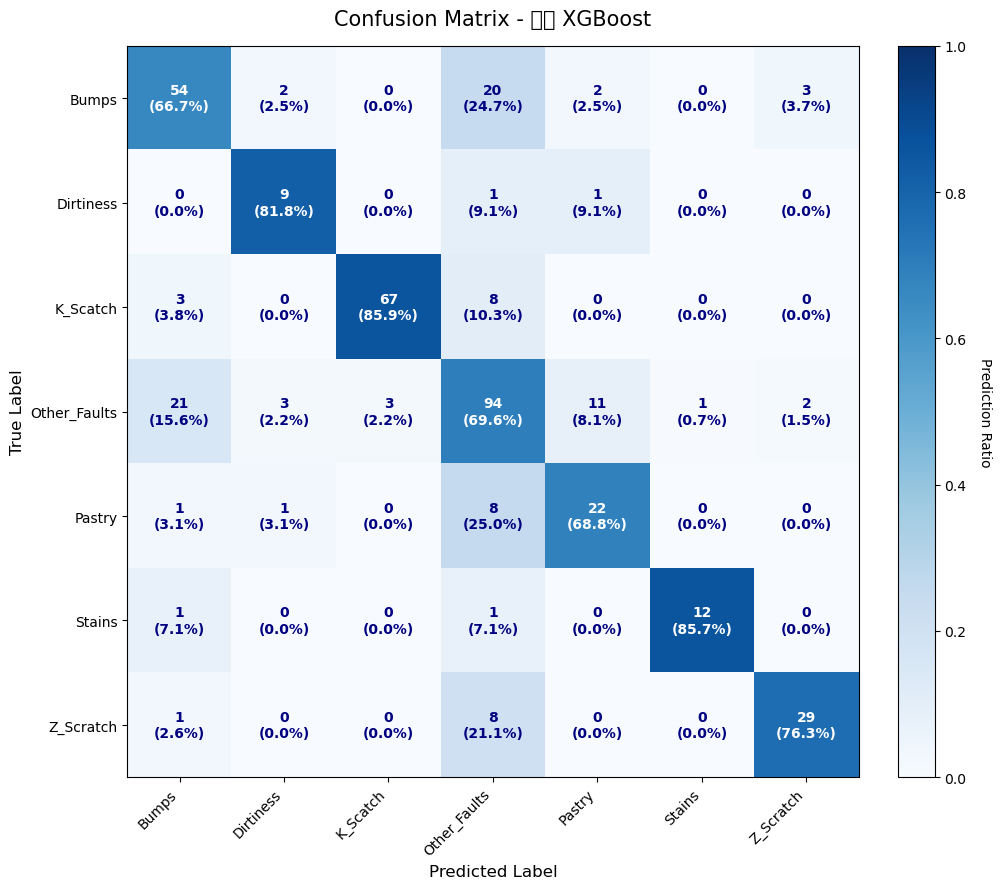

In [28]:
# --------------------------------------------------
# 혼동행렬
# --------------------------------------------------
confusion = confusion_matrix(y_test_text, y_pred, labels=class_names)
row_sum = confusion.sum(axis=1, keepdims=True)

confusion_ratio = np.divide(
    confusion.astype(float),
    row_sum,
    out=np.zeros_like(confusion, dtype=float),
    where=row_sum != 0
)

fig, ax = plt.subplots(figsize=(11, 9))
image = ax.imshow(confusion_ratio, cmap='Blues', vmin=0, vmax=1)

ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)

for row in range(len(class_names)):
    for column in range(len(class_names)):
        count = confusion[row, column]
        ratio = confusion_ratio[row, column]
        text_color = 'white' if ratio >= 0.5 else 'navy'

        ax.text(
            column, row,
            f'{count}\n({ratio:.1%})',
            ha='center', va='center',
            color=text_color,
            fontsize=10,
            fontweight='bold'
        )

ax.set_title(f'Confusion Matrix - {final_model_name}', fontsize=15, pad=15)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)

colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
colorbar.set_label('Prediction Ratio', rotation=270, labelpad=18)

plt.tight_layout()
plt.show()

**[16] 튜닝 XGBoost 피처 중요도**

In [29]:
# --------------------------------------------------
# 튜닝 모델의 Gain 기반 피처 중요도
# --------------------------------------------------
fitted_model = best_pipeline.named_steps['model']

feature_importanceDF = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': fitted_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

feature_importanceDF['Rank'] = feature_importanceDF.index + 1
feature_importanceDF = feature_importanceDF[['Rank', 'Feature', 'Importance']]

display(feature_importanceDF.round(4))

,Rank,Feature,Importance
0,1,Outside_X_Index,0.1685
1,2,TypeOfSteel_A300,0.1618
2,3,Pixels_Areas,0.1315
3,4,Steel_Plate_Thickness,0.0907
4,5,Edges_Y_Index,0.0710
5,6,Square_Index,0.0707
6,7,X_Perimeter,0.0703
7,8,Y_Perimeter,0.0646
8,9,Edges_X_Index,0.0554
9,10,Edges_Index,0.0411


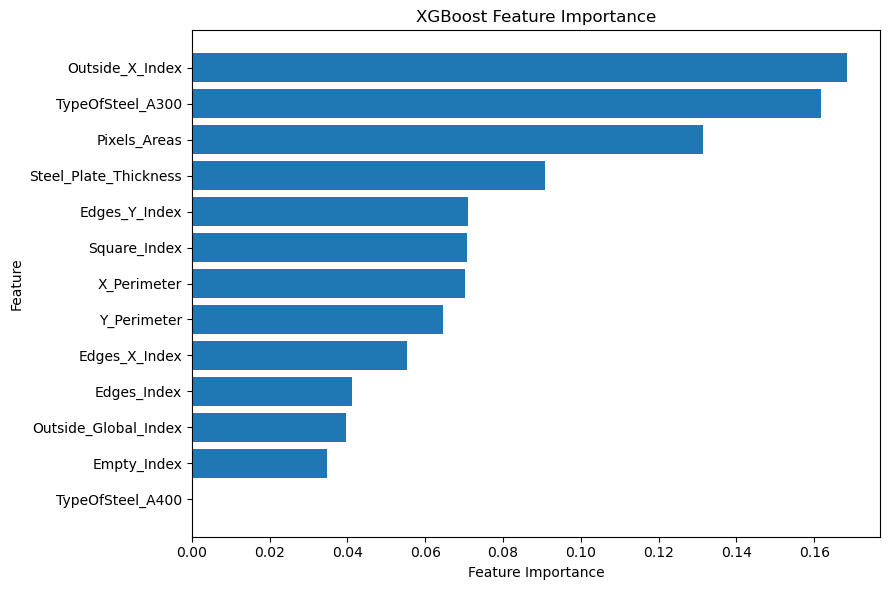

In [21]:
# --------------------------------------------------
# 피처 중요도 시각화
# --------------------------------------------------
plt.figure(figsize=(9, 6))
plt.barh(feature_importanceDF['Feature'], feature_importanceDF['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

**[17] 튜닝 모델 평가점수(비교용)**

In [22]:
# --------------------------------------------------
# 튜닝 모델 평가점수
# --------------------------------------------------
y_train_pred_encoded = best_pipeline.predict(X_train)
y_test_pred_encoded = best_pipeline.predict(X_test)

y_train_pred = labelEncoder.inverse_transform(y_train_pred_encoded.astype(int))
y_pred = labelEncoder.inverse_transform(y_test_pred_encoded.astype(int))

train_accuracy = accuracy_score(y_train_text, y_train_pred)
test_accuracy = accuracy_score(y_test_text, y_pred)
test_precision_macro = precision_score(y_test_text, y_pred, average='macro', zero_division=0)
test_recall_macro = recall_score(y_test_text, y_pred, average='macro', zero_division=0)
test_f1_macro = f1_score(y_test_text, y_pred, average='macro', zero_division=0)
test_f1_weighted = f1_score(y_test_text, y_pred, average='weighted', zero_division=0)
overfit_gap = train_accuracy - test_accuracy

tuned_scoreDF = pd.DataFrame({
    '평가지표': [
        'Train Accuracy', 'Test Accuracy',
        'Test Precision Macro', 'Test Recall Macro',
        'Test F1 Macro', 'Test F1 Weighted',
        'Train-Test Accuracy Gap'
    ],
    '점수': [
        train_accuracy, test_accuracy,
        test_precision_macro, test_recall_macro,
        test_f1_macro, test_f1_weighted,
        overfit_gap
    ]
})

display(tuned_scoreDF.round(4))

,평가지표,점수
0,Train Accuracy,0.8744
1,Test Accuracy,0.7198
2,Test Precision Macro,0.7409
3,Test Recall Macro,0.7245
4,Test F1 Macro,0.7301
5,Test F1 Weighted,0.7244
6,Train-Test Accuracy Gap,0.1546


**[18] 한계 및 향후 개선**

### 한계
- `Dirtiness`, `Stains`의 표본 수가 적음
- Random Forest의 Train-Test 차이가 큼
- 피처 중요도는 인과관계가 아니라 모델이 분류에 사용한 정도를 의미함
- RandomizedSearchCV의 탐색 조합 수가 제한적임

### 향후 개선
- `n_iter`를 20~30회로 확대
    * 더 적절한 max_depth, n_estimators, min_samples_split 가능성 증가
    * 너무 오래걸림
- 소수 클래스에 `sample_weight` 적용
    * 소수 클래스가 Other_Faults로 몰리는 현상 감소
    * 다른 결함을 소수 클래스로 잘못 판단할 가능성도 존재
- `Pastry`와 `Other_Faults`의 오분류 원인 분석
- 10000개 이상의 행과 적당한 수의 컬럼 데이터셋 선택

### 결론
결함 크기 특성 중 `Pixels_Areas`는 두 모델에서 모두 상위 중요 피처로 나타났고, X·Y 방향 둘레도 결함 분류에 기여했다. 철판 두께와 경계·형상 피처가 함께 활용된 결과, 결함 유형은 하나의 특성이 아니라 철판 조건과 결함의 크기·형상이 결합된 패턴으로 구분된다고 해석할 수 있다. 다만 두 모델의 정확한 비교를 위해서는 동일한 피처 구성으로 재학습할 필요가 있다.